In [3]:
# ============================================
# TECH CHALLENGE - FASE 1
# Classificação de Câncer de Mama
# ============================================

# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Carregando o dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Visualizando as primeiras linhas
print("Shape do dataset:", df.shape)
print("\nPrimeiras linhas:")
df.head()

Shape do dataset: (569, 31)

Primeiras linhas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached numba-0.65.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
# ============================================
# ETAPA 2 - Análise Exploratória dos Dados
# ============================================

# Estatísticas descritivas
print("=== Informações do Dataset ===")
print(df.info())

print("\n=== Estatísticas Descritivas ===")
df.describe()


=== Informações do Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


C:\Users\sabri\AppData\Local\Temp\ipykernel_20388\3580283399.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


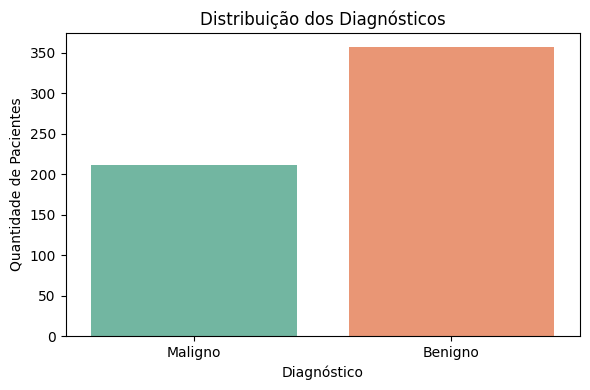

target
1    357
0    212
Name: count, dtype: int64

Malignos: 212 pacientes
Benignos: 357 pacientes


In [5]:
# ============================================
# ETAPA 2 - Visualizações
# ============================================

# Gráfico 1: Distribuição dos diagnósticos
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribuição dos Diagnósticos')
plt.xticks([0, 1], ['Maligno', 'Benigno'])
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de Pacientes')
plt.tight_layout()
plt.show()

# Contagem
print(df['target'].value_counts())
print(f"\nMalignos: {(df['target']==0).sum()} pacientes")
print(f"Benignos: {(df['target']==1).sum()} pacientes")

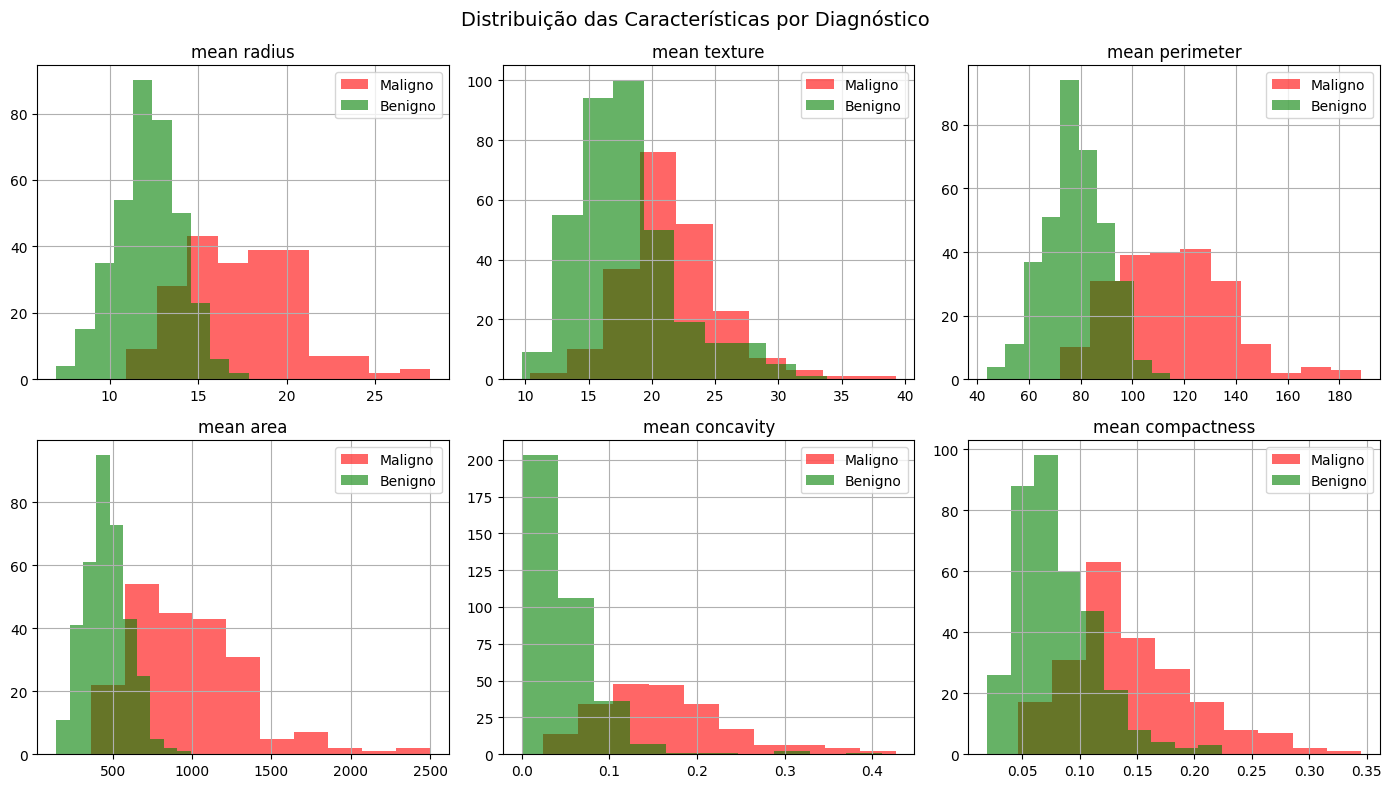

In [6]:
# Gráfico 2: Comparação das principais características
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

features = ['mean radius', 'mean texture', 'mean perimeter',
            'mean area', 'mean concavity', 'mean compactness']

for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    df[df['target']==0][feature].hist(ax=ax, alpha=0.6, color='red', label='Maligno')
    df[df['target']==1][feature].hist(ax=ax, alpha=0.6, color='green', label='Benigno')
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Distribuição das Características por Diagnóstico', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# ETAPA 3 - Pré-processamento
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando features e target
X = df.drop('target', axis=1)
y = df['target']

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 455 amostras
Teste:  114 amostras


In [8]:
# ============================================
# ETAPA 4 - Treinamento dos Modelos
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

# Modelo 1: Regressão Logística
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

# Modelo 2: Árvore de Decisão
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)
pred_dt = modelo_dt.predict(X_test)

# Resultados
print("=== REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, pred_lr, target_names=['Maligno', 'Benigno']))

print("=== ÁRVORE DE DECISÃO ===")
print(classification_report(y_test, pred_dt, target_names=['Maligno', 'Benigno']))

=== REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

     Maligno       0.98      0.95      0.96        43
     Benigno       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

=== ÁRVORE DE DECISÃO ===
              precision    recall  f1-score   support

     Maligno       0.93      0.93      0.93        43
     Benigno       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



C:\Users\sabri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


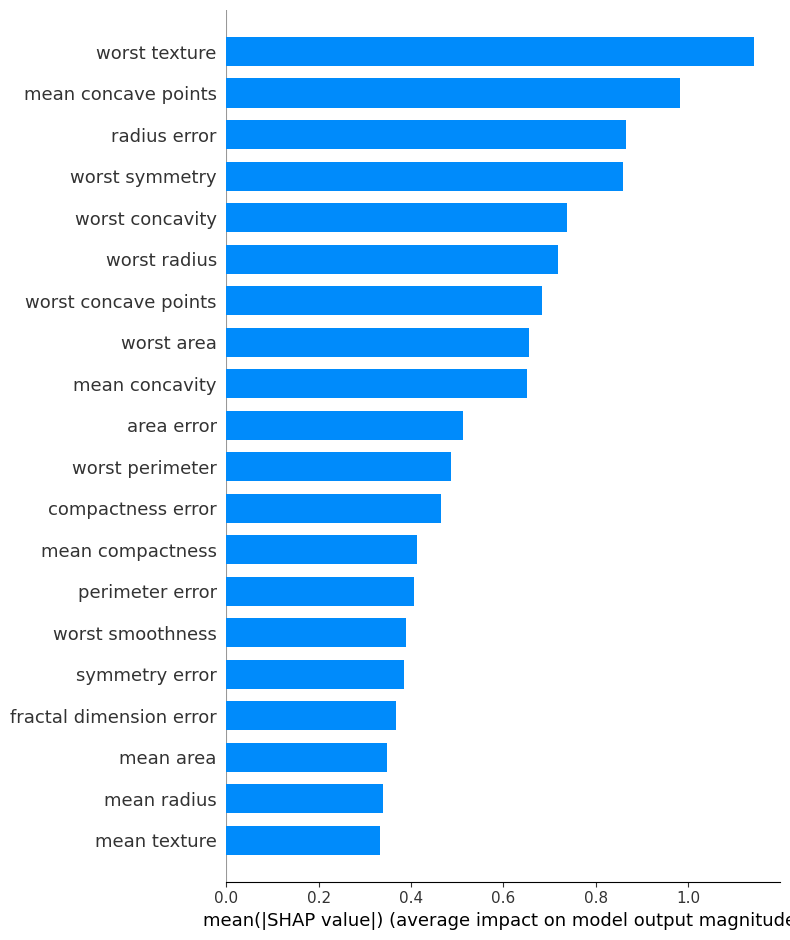

In [9]:
# ============================================
# ETAPA 5 - Explicabilidade com SHAP
# ============================================
import shap

# Criando o explicador
explainer = shap.LinearExplainer(modelo_lr, X_train)
shap_values = explainer.shap_values(X_test)

# Gráfico de importância das features
shap.summary_plot(shap_values, X_test, 
                  feature_names=data.feature_names,
                  plot_type="bar",
                  show=True)